# MISO Subregion Load-Forecast Validation

This notebook compares the archived direct total-MISO 2023 TELL forecast and the
hourly sum of the six archived MISO subregion forecasts against the same cleaned
EIA-930 total-MISO actual-load series.


## 1. Imports and archived paths

Run this notebook from `paper_data/validation`. No online acquisition is required.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_ROOT = Path("../data")
HISTORICAL_ROOT = DATA_ROOT / "wtk_bchrrr_nsrdb_2007_2023"
SOURCE_INPUT_ROOT = DATA_ROOT / "source_inputs"

if not DATA_ROOT.is_dir():
    raise FileNotFoundError("Expected the merged release data at ../data.")


## 2. Read actual load and the direct MISO forecast

Both series are restricted to the 8,760 UTC hours of 2023 and must be unique by
timestamp.


In [2]:
YEAR = 2023
EXPECTED_HOURS = 8_760

actual_path = SOURCE_INPUT_ROOT / "load_actuals_cleaned_2023" / "MISO_cleaned_load_2023.csv"
direct_path = HISTORICAL_ROOT / "ba_load" / "MISO_wtk_bchrrr_nsrdb_2007_2023_load.csv"

actual = pd.read_csv(
    actual_path,
    usecols=["time_utc", "load_actual_mw_raw", "load_actual_mw_clean", "load_clean_flag", "load_clean_reason"],
)
actual["time_utc"] = pd.to_datetime(actual["time_utc"], utc=True)
actual = actual.loc[actual["time_utc"].dt.year.eq(YEAR)].copy()

direct = pd.read_csv(direct_path, usecols=["time_utc", "load_mw"])
direct["time_utc"] = pd.to_datetime(direct["time_utc"], utc=True)
direct = direct.loc[direct["time_utc"].dt.year.eq(YEAR)].copy()
direct.rename(columns={"load_mw": "direct_forecast_mw"}, inplace=True)

for label, frame in [("actual", actual), ("direct forecast", direct)]:
    if len(frame) != EXPECTED_HOURS or frame["time_utc"].duplicated().any():
        raise AssertionError(f"The {label} series must contain 8,760 unique 2023 hours.")

display(pd.DataFrame({"series": ["cleaned actual", "direct MISO forecast"], "hours": [len(actual), len(direct)]}))


,series,hours
0,cleaned actual,8760
1,direct MISO forecast,8760


## 3. Sum the six MISO subregion forecasts

All six subregions are aligned by UTC timestamp before summation. `min_count=6`
prevents an incomplete hour from being treated as a valid MISO total.


In [3]:
MISO_SUBREGIONS = ["MISO_0001", "MISO_0004", "MISO_0006", "MISO_0027", "MISO_0035", "MISO_8910"]
subregion_series = []
subregion_rows = []

for subregion in MISO_SUBREGIONS:
    path = HISTORICAL_ROOT / "ba_load" / f"{subregion}_wtk_bchrrr_nsrdb_2007_2023_load.csv"
    frame = pd.read_csv(path, usecols=["time_utc", "load_mw"])
    frame["time_utc"] = pd.to_datetime(frame["time_utc"], utc=True)
    frame = frame.loc[frame["time_utc"].dt.year.eq(YEAR)].copy()
    if len(frame) != EXPECTED_HOURS or frame["time_utc"].duplicated().any():
        raise AssertionError(f"Incomplete or duplicate 2023 forecast hours for {subregion}.")

    series = frame.set_index("time_utc")["load_mw"].rename(subregion)
    subregion_series.append(series)
    subregion_rows.append({"subregion": subregion, "hours": len(series), "mean_forecast_mw": series.mean()})

subregions_wide = pd.concat(subregion_series, axis=1).sort_index()
if list(subregions_wide.columns) != MISO_SUBREGIONS or subregions_wide.isna().any().any():
    raise AssertionError("The six MISO subregion forecasts are not fully aligned.")

subregion_sum = subregions_wide.sum(axis=1, min_count=len(MISO_SUBREGIONS)).rename("subregion_sum_forecast_mw")
display(pd.DataFrame(subregion_rows))


,subregion,hours,mean_forecast_mw
0,MISO_0001,8760,10470.496354
1,MISO_0004,8760,5265.515261
2,MISO_0006,8760,9797.756498
3,MISO_0027,8760,17767.223424
4,MISO_0035,8760,9914.571723
5,MISO_8910,8760,19688.420519


## 4. Build the common hourly comparison and calculate metrics

Forecast error is forecast minus cleaned actual load. Both forecast methods use
identical hours and the same actual-load denominator.


In [4]:
comparison = actual.merge(direct, on="time_utc", how="inner", validate="one_to_one")
comparison = comparison.merge(subregion_sum.reset_index(), on="time_utc", how="inner", validate="one_to_one")
if len(comparison) != EXPECTED_HOURS or comparison[
    ["load_actual_mw_clean", "direct_forecast_mw", "subregion_sum_forecast_mw"]
].isna().any().any():
    raise AssertionError("The MISO comparison must contain three complete, aligned 2023 series.")

metric_rows = []
for label, forecast_column in [
    ("Direct total MISO", "direct_forecast_mw"),
    ("Sum of six MISO subregions", "subregion_sum_forecast_mw"),
]:
    actual_values = comparison["load_actual_mw_clean"]
    forecast_values = comparison[forecast_column]
    error = forecast_values - actual_values
    rmse = float(np.sqrt(np.mean(np.square(error))))
    nonzero = actual_values.ne(0)
    metric_rows.append(
        {
            "forecast": label,
            "hours_compared": len(comparison),
            "mae_mw": float(error.abs().mean()),
            "rmse_mw": rmse,
            "nrmse_mean_actual": rmse / float(actual_values.mean()),
            "mape": float((error.loc[nonzero].abs() / actual_values.loc[nonzero].abs()).mean()),
            "r2": float(1.0 - np.square(error).sum() / np.square(actual_values - actual_values.mean()).sum()),
            "bias_mw": float(error.mean()),
        }
    )

metrics = pd.DataFrame(metric_rows)
if not np.isfinite(metrics.select_dtypes(include="number").to_numpy()).all():
    raise AssertionError("MISO validation metrics must all be finite.")
display(metrics.round(3))


,forecast,hours_compared,mae_mw,rmse_mw,nrmse_mean_actual,mape,r2,bias_mw
0,Direct total MISO,8760,1475.639,1914.049,0.026,0.021,0.970,-320.405
1,Sum of six MISO subregions,8760,1182.629,1603.436,0.022,0.016,0.979,-265.810


## 5. Direct and subregion-sum scatter plot

The shared one-to-one line makes the two forecast approaches directly comparable.


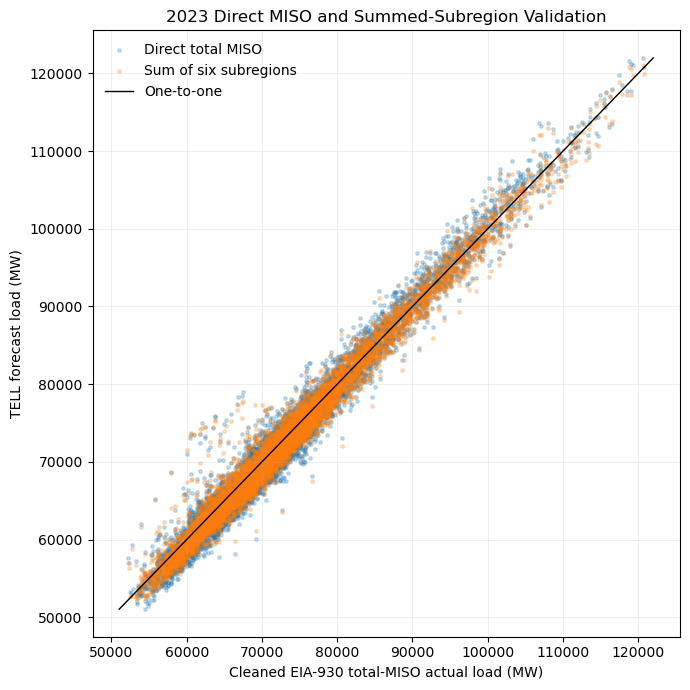

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    comparison["load_actual_mw_clean"],
    comparison["direct_forecast_mw"],
    s=6,
    alpha=0.24,
    label="Direct total MISO",
    rasterized=True,
)
ax.scatter(
    comparison["load_actual_mw_clean"],
    comparison["subregion_sum_forecast_mw"],
    s=6,
    alpha=0.24,
    label="Sum of six subregions",
    rasterized=True,
)

limits = [
    comparison[["load_actual_mw_clean", "direct_forecast_mw", "subregion_sum_forecast_mw"]].min().min(),
    comparison[["load_actual_mw_clean", "direct_forecast_mw", "subregion_sum_forecast_mw"]].max().max(),
]
ax.plot(limits, limits, color="black", linewidth=1, label="One-to-one")
ax.set_xlabel("Cleaned EIA-930 total-MISO actual load (MW)")
ax.set_ylabel("TELL forecast load (MW)")
ax.set_title("2023 Direct MISO and Summed-Subregion Validation")
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Interpretation

Use the common metric table to assess whether reconstructing MISO from the six
subregions materially changes forecast agreement relative to the direct model.
